# 05 · Recreating the figures from the paper
The `paper_figures` module reproduces the explanatory diagrams from Angelopoulos & Bates (2022) as clean, editable Matplotlib figures — ready for slides. The classification illustrations use the same 5-class severity target (0 = none … 4 = critical) that notebooks 00–04 actually predict, so the multiclass picture here matches the workshop's main task, not just a toy example; the regression illustrations use small synthetic examples, exactly as the paper does.

In [1]:
# --- workshop bootstrap: make the package importable ---
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))
import numpy as np, pandas as pd
from fedconformal import data, conformal, evaluate as ev, federated, heterogeneity as het, viz, eda, paper_figures as pf
viz.set_style()
%matplotlib inline
# load the federation once (each notebook is self-contained)
df = data.load_raw()
sites = data.load_sites(shared_scaler=True)

## Figure 1 — Prediction set examples
Unlike every other figure in this notebook, Figure 1 is **not** illustrative: it trains the real federated model, calibrates a real APS conformal predictor, and picks three real patients — all truly *No disease* — whose prediction sets grow from a confident singleton to a 4-class set in which *No disease* is not even the model's top guess. That mirrors the paper's own fox-squirrel panel, where the third photo fools the classifier into ranking *marmot* above the true class, yet the true class still survives inside the set.

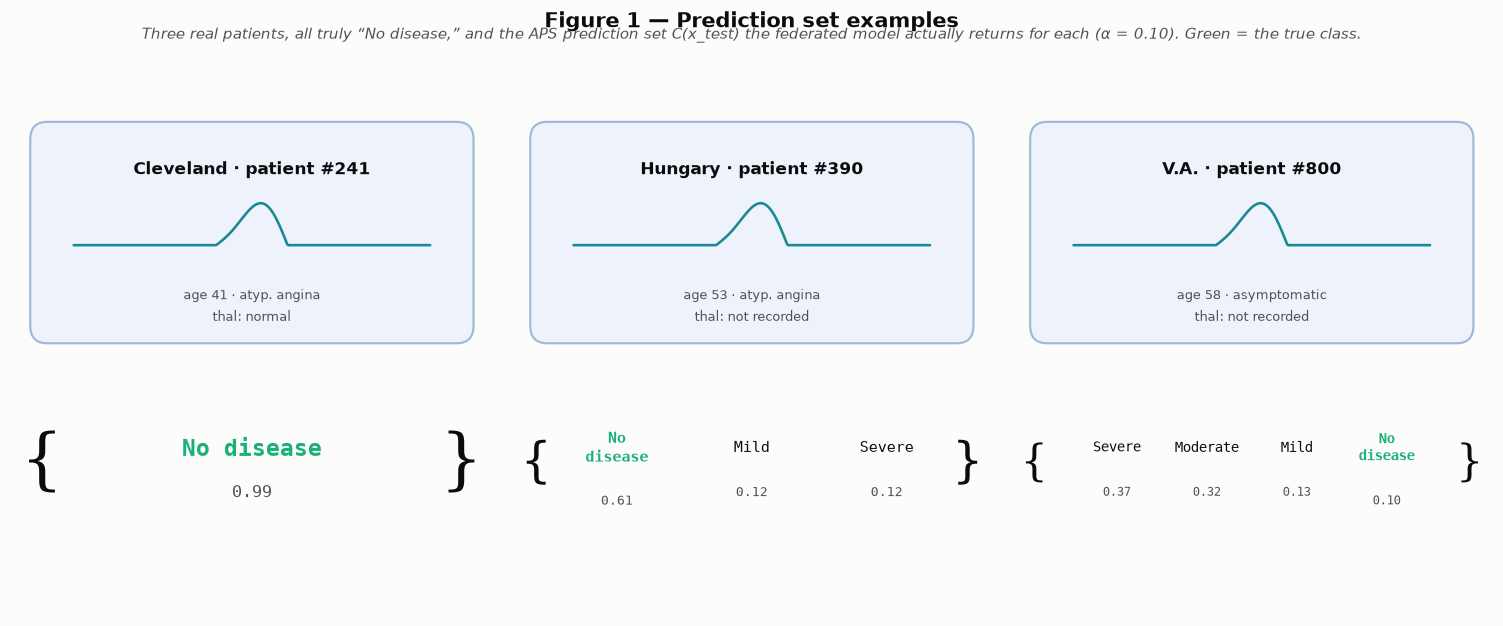

In [2]:
pf.fig01_prediction_set_examples();

## Figure 2 — Illustration of conformal prediction
Compute a score on a holdout point → take the quantile q̂ → form the prediction set for a new point by keeping every class with softmax ≥ 1 − q̂.

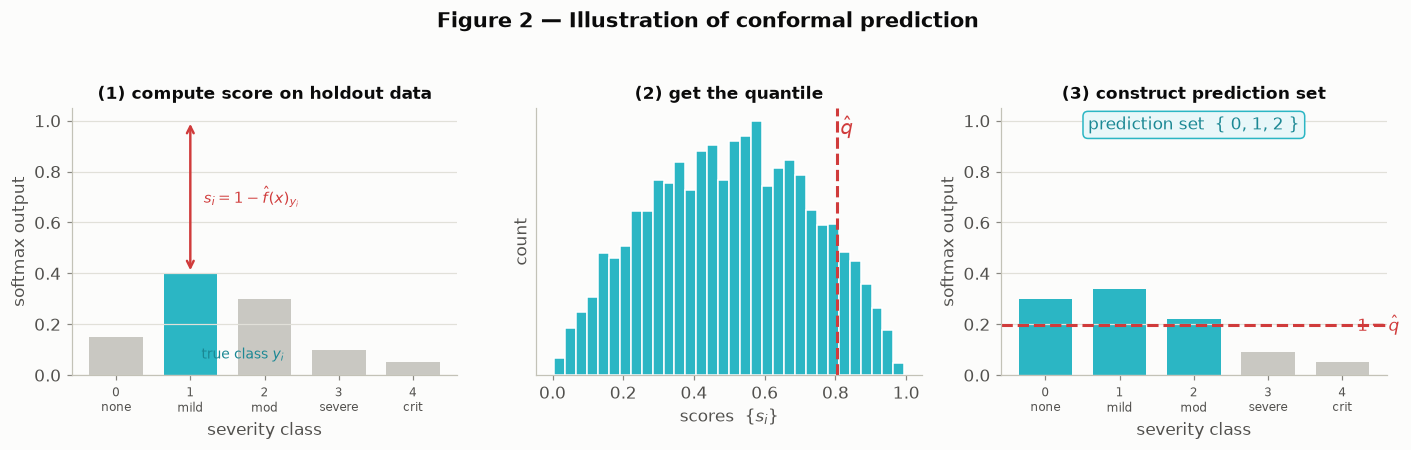

In [3]:
pf.fig02_conformal_illustration();

## Figure 4 — Adaptive Prediction Sets (APS)
Sort classes by softmax and accumulate until the cumulative mass crosses q̂; the classes below the cut form the (adaptive) prediction set.

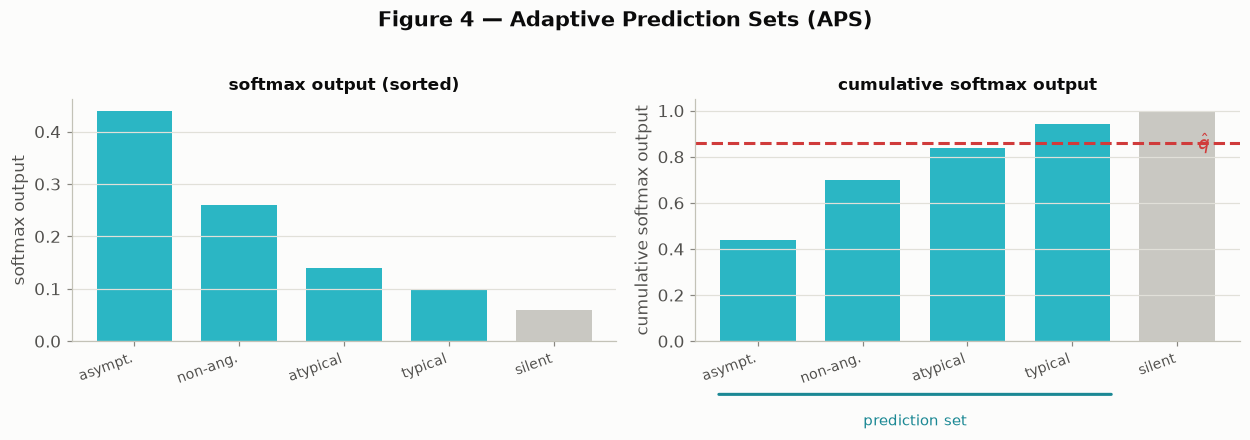

In [4]:
pf.fig04_aps_illustration();

## Figure 6 — Conformalized Quantile Regression
Fitted quantile curves, then widened by q̂ to reach the coverage guarantee.

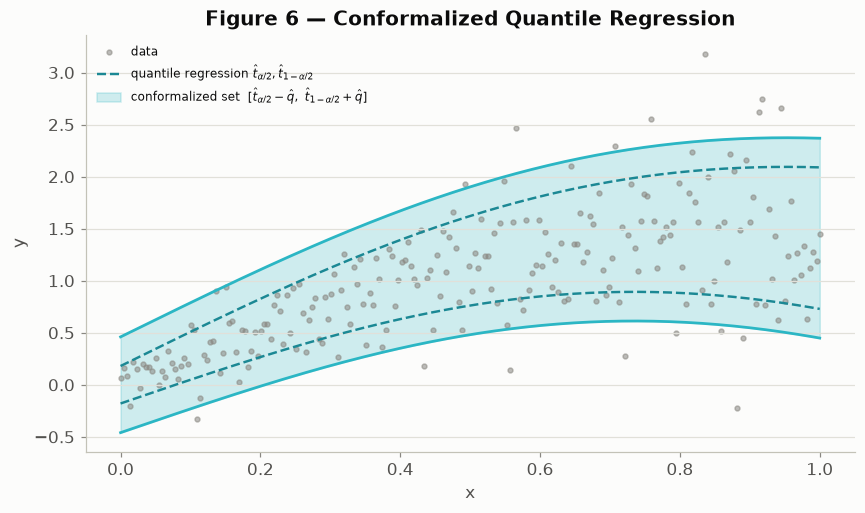

In [5]:
pf.fig06_cqr_illustration();

## Figure 8 — Conformalized uncertainty scalar
A point prediction f(x) with a symmetric band q̂·u(x).

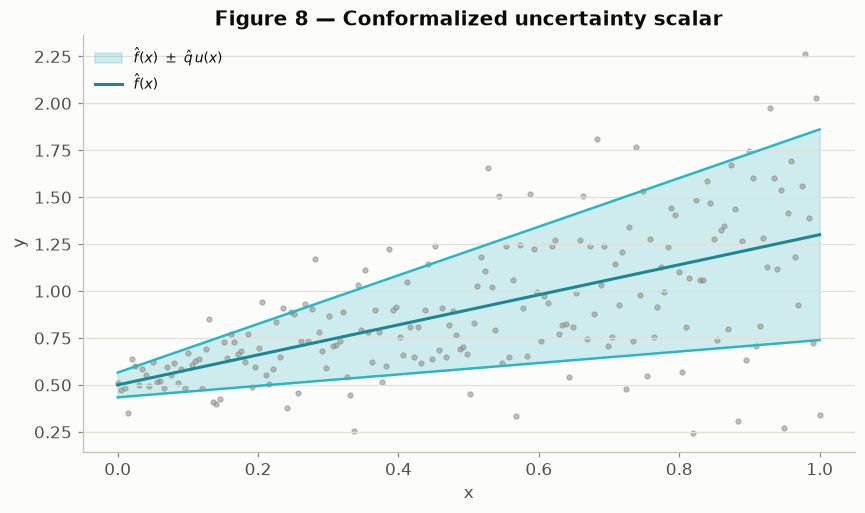

In [6]:
pf.fig08_uncertainty_scalar();

## Figure 9 — Conformalized Bayes
The prediction set is the *superlevel set* of the posterior predictive density: { y : f(y|x) ≥ threshold }.

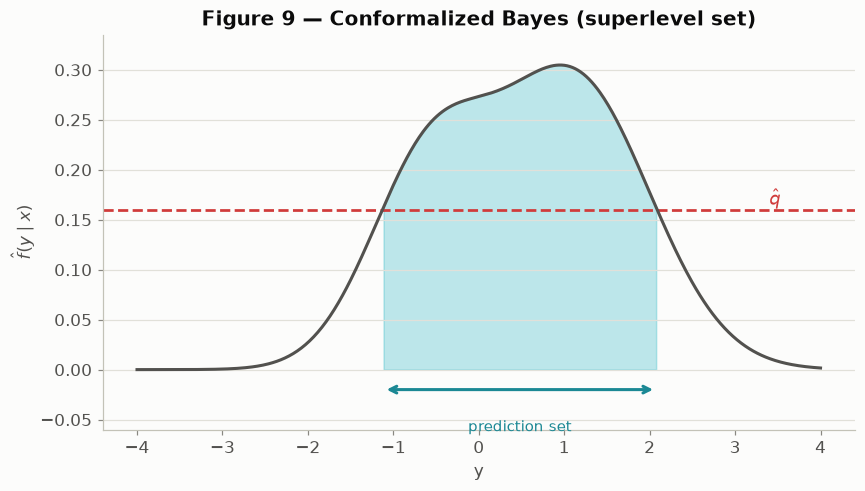

In [7]:
pf.fig09_bayes_superlevel();

## Figure 10 — Notions of coverage
No coverage vs. marginal-only vs. conditional. Framed here as two **sites**: marginal coverage can hit 90% overall while one site is badly under-covered; conditional coverage requires 90% *at every site*. This is the workshop's core distinction.

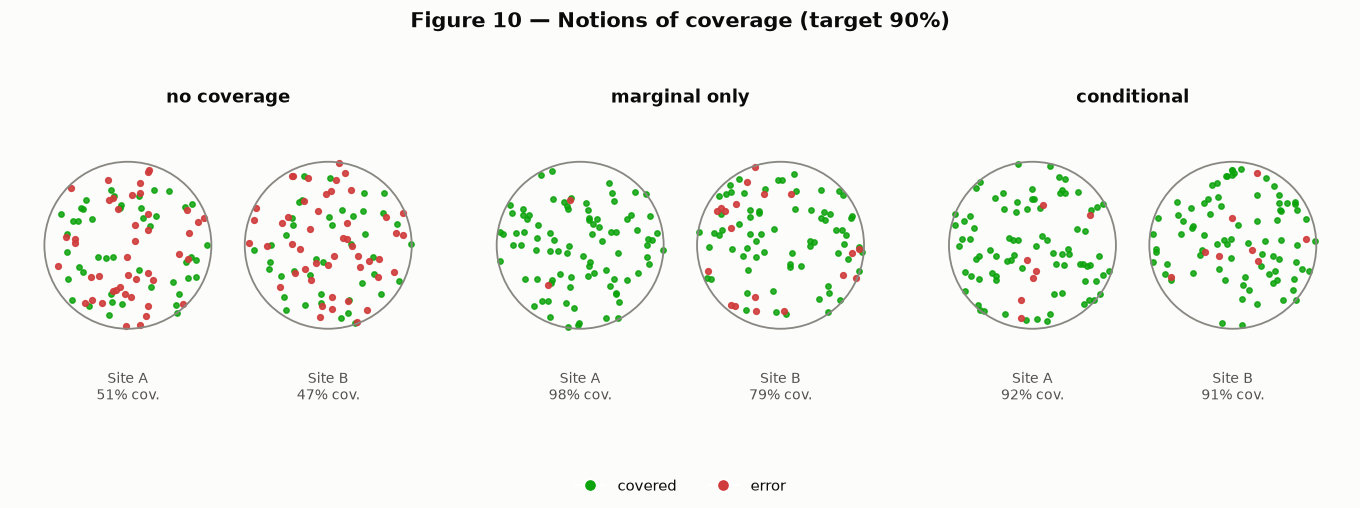

In [8]:
pf.fig10_coverage_notions();

## Figure 11 — Distribution of coverage vs. calibration-set size
Coverage is itself random (it depends on the calibration draw); its Beta distribution narrows around 1 − α as the calibration set grows.

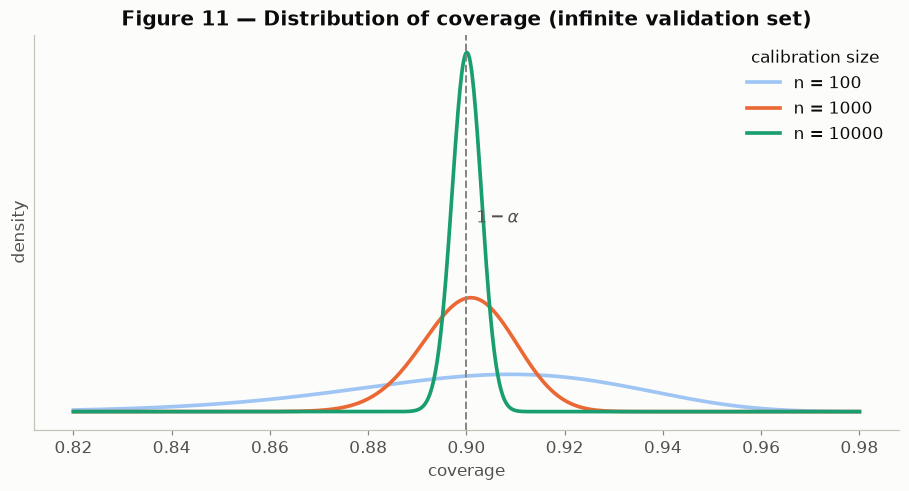

In [9]:
pf.fig11_coverage_distribution();

### Exercise
Every function takes keyword arguments (e.g. `alpha`, `ns`, `seed`). Regenerate Figure 11 with `ns=(30, 100, 300)` and Figure 2 with `alpha=0.2`. How does a larger α change q̂ and the size of the prediction set?